# Proper Analysis of Dataset

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_df = pd.read_csv("datasets/train.csv")
test_df = pd.read_csv("datasets/test.csv")

## What Data is in the Dataset

In [6]:
print(train_df.columns)

Index(['client_id', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default'],
      dtype='str')


| Column | Description |
|--------|-------------|
| `client_id` | non-informative competition identifier |
| `LIMIT_BAL` | granted credit in NT dollars |
| `SEX` | source-coded sex category |
| `EDUCATION` | source-coded education category |
| `MARRIAGE` | source-coded marital-status category |
| `AGE` | age in years |
| `PAY_0`, `PAY_2` ... `PAY_6` | recent repayment-status history |
| `BILL_AMT1` ... `BILL_AMT6` | monthly bill statement amounts in NT dollars |
| `PAY_AMT1` ... `PAY_AMT6` | monthly previous-payment amounts in NT dollars |
| `default` | training target; 1 = default, 0 = no default |

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  24000 non-null  str  
 1   LIMIT_BAL  24000 non-null  int64
 2   SEX        24000 non-null  int64
 3   EDUCATION  24000 non-null  int64
 4   MARRIAGE   24000 non-null  int64
 5   AGE        24000 non-null  int64
 6   PAY_0      24000 non-null  int64
 7   PAY_2      24000 non-null  int64
 8   PAY_3      24000 non-null  int64
 9   PAY_4      24000 non-null  int64
 10  PAY_5      24000 non-null  int64
 11  PAY_6      24000 non-null  int64
 12  BILL_AMT1  24000 non-null  int64
 13  BILL_AMT2  24000 non-null  int64
 14  BILL_AMT3  24000 non-null  int64
 15  BILL_AMT4  24000 non-null  int64
 16  BILL_AMT5  24000 non-null  int64
 17  BILL_AMT6  24000 non-null  int64
 18  PAY_AMT1   24000 non-null  int64
 19  PAY_AMT2   24000 non-null  int64
 20  PAY_AMT3   24000 non-null  int64
 21  PAY_AMT4   24000 non-nu

In [21]:
train_df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,167608.736667,1.601792,1.850708,1.547958,35.540708,-0.019875,-0.137042,-0.168542,-0.225000,-0.269667,...,43175.799292,40271.754333,38743.087125,5711.710125,5.955190e+03,5262.745792,4853.362792,4749.935125,5161.937458,0.221208
std,130130.702503,0.489539,0.795213,0.521898,9.255129,1.125514,1.199960,1.202787,1.172113,1.135635,...,64534.910992,60980.478739,59707.335820,17155.309436,2.435021e+04,18426.028570,15752.040523,14873.057360,17925.431411,0.415069
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-65167.000000,-61372.000000,-209051.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2300.750000,1710.250000,1206.000000,992.500000,7.800000e+02,390.000000,298.750000,212.750000,100.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18932.000000,18021.500000,16926.500000,2100.000000,2.000000e+03,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54341.500000,49937.500000,48904.750000,5004.000000,5.000000e+03,4500.000000,4001.250000,4005.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,417990.000000,528666.000000,1.000000


## Repayment Status 

So everything besides the client_id is given as in integer There are no NaN entries. The PAY_0, PAY_2, ... , PAY_6 columns give information about the repayment statuses in the months leading up to the date at which the data is collected. Assuming the month of creation is September, PAY_0 refers to the repayment status in September, PAY_2 refers to the repayment status in August etc...

| Values | Description |
|--------|-------------|
| -2 | No Balance / No Credit Used |
| -1 | Paid in Full -> Customer completely paid off the charge on the card |
| 0 | Paid Minimum Amount -> Customer used the card and paid off the min amount |
| 1 | Payment has been delayed by 1 month | 
| 2 | Payment has been delayed by 2 months | 
| 3 | Payment has been delayed by 3 months | 
| 4 | Payment has been delayed by 4 months |
| 5 | Payment has been delayed by 5 months | 
| 6 | Payment has been delayed by 6 months |
| 7 | Payment has been delayed by 7 months |
| 8 | Payment has been delayed by 8 months |
| 9 | Payment has been delayed by 9+ months (This value doesn't appear in the training dataset) |

In [12]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    train_df[col] = train_df[col].replace([-1, -2], 0)

Because the values for -2, -1 and 0 realistically serve no difference, all showing the person has paid on time, we will group this together to all be equal to 0.

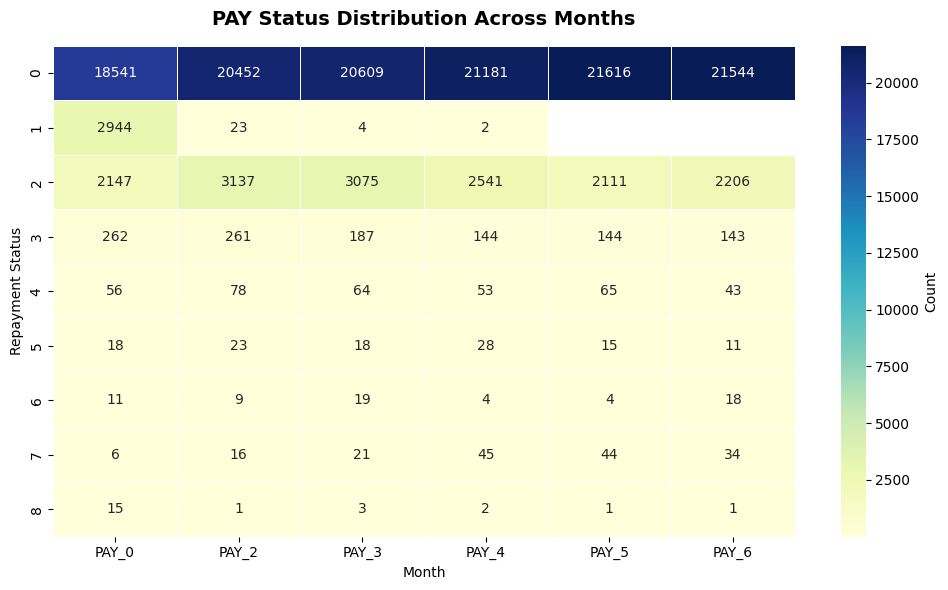

In [18]:
pay_status_dist = train_df[pay_cols].apply(pd.Series.value_counts)
plt.figure(figsize=(10, 6))
sns.heatmap(
    pay_status_dist,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',           # or 'rocket', 'mako', 'viridis', 'coolwarm'
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Count'},
    square=False
)
plt.title('PAY Status Distribution Across Months', fontsize=14, weight='bold', pad=15)
plt.xlabel('Month')
plt.ylabel('Repayment Status')
plt.tight_layout()
plt.show()

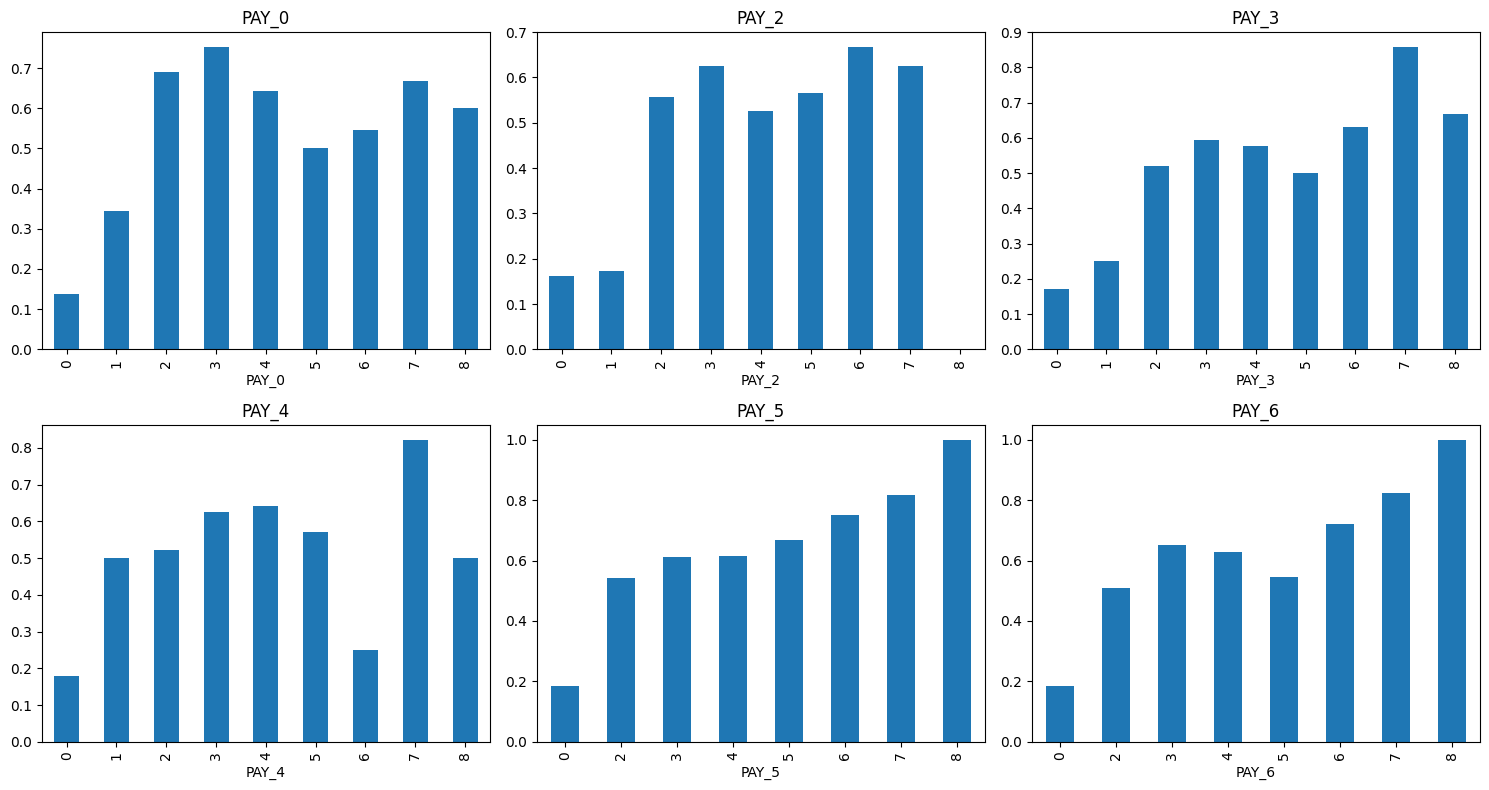

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), pay_cols):
    train_df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, title=col)
plt.tight_layout()

The above graph shows the percentage of people who defaulted at every given pay status level at every given time period.

## Marriage, Education and Sex

### Marriage
The Marriage column has 4 variables (0, 1, 2, 3)  
The marriage statuses are defined as such:
- **0**: Unknown
- **1**: Married
- **2**: Single
- **3**: Other

We will proceed to categorise unknown to be the same as other.

In [22]:
train_df['MARRIAGE'] = train_df['MARRIAGE'].replace([0], 3)

#### Sex
The sex column only has 2 variables (1, 2).  
The sex statuses are defined as:
- **1**: Male
- **2**: Female
As such, there is no need to perform any further work on this  

### Education
The education column has 7 variables (0, 1, 2, 3, 4, 5, 6). However, offically only the following are defined:  
- **1**: Graduate School
- **2**: University
- **3**: High School
- **4**: Other
As such, we will group everything classified as 0, 5 and 6 into other.

In [24]:
train_df['EDUCATION'] = train_df['EDUCATION'].replace([0, 5, 6], 4)

## Exporting Cleaned DataSet

In [25]:
train_df.to_csv('train_clean.csv', index=False)